# Памперсы или пиво? Практический проект по созданию рекомендательной системы

### Подготовка <a class="anchor" id="prepare">#</a>

In [1]:
# preload local libs
import sys
import os
import pathlib

project_dir = str(pathlib.Path(os.getcwd()).parent.resolve())
if project_dir not in sys.path:
    sys.path.insert(1, project_dir)

# project_dir

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import json
import gzip
import scipy.sparse as sparse
import implicit

from tqdm import tqdm_notebook
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from collections import Counter
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.base import BaseEstimator


import warnings
warnings.filterwarnings("ignore")

DATA_DIR = project_dir + '/hw-10/data'
ARTIFACTS_DIR = project_dir + '/hw-10/artifacts'

### Загрузка данных<a class="anchor" id="data_load">#</a>

Использую небольшой набор данных "All Beauty" (https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/)

In [3]:
def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield json.loads(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')

path = os.path.join(DATA_DIR, 'All_Beauty_5.json.gz')
df_src = getDF(path)

In [4]:
df_src.head()

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,5.0,True,"09 1, 2016",A3CIUOJXQ5VDQ2,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Shelly F,As advertised. Reasonably priced,Five Stars,1472688000,NaN,NaN
1,5.0,True,"11 14, 2013",A3H7T87S984REU,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",houserules18,Like the oder and the feel when I put it on my...,Good for the face,1384387200,NaN,NaN
2,1.0,True,"08 18, 2013",A3J034YH7UG4KT,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Adam,I bought this to smell nice after I shave. Wh...,Smells awful,1376784000,NaN,NaN
3,5.0,False,"05 3, 2011",A2UEO5XR3598GI,B0000530HU,"{'Size:': ' 7.0 oz', 'Flavor:': ' Classic Ice ...",Rich K,HEY!! I am an Aqua Velva Man and absolutely lo...,Truth is There IS Nothing Like an AQUA VELVA MAN.,1304380800,25,NaN
4,5.0,True,"05 6, 2011",A3SFRT223XXWF7,B00006L9LC,{'Size:': ' 200ml/6.7oz'},C. C. Christian,If you ever want to feel pampered by a shampoo...,Bvlgari Shampoo,1304640000,3,NaN


In [5]:
# Оставим только нужное

df = df_src[["reviewerID", "asin", "overall", "unixReviewTime"]].copy()
df.columns = ["user_id", "item_id", "rating", "timestamp"]

df.head()

,user_id,item_id,rating,timestamp
0,A3CIUOJXQ5VDQ2,B0000530HU,5.0,1472688000
1,A3H7T87S984REU,B0000530HU,5.0,1384387200
2,A3J034YH7UG4KT,B0000530HU,1.0,1376784000
3,A2UEO5XR3598GI,B0000530HU,5.0,1304380800
4,A3SFRT223XXWF7,B00006L9LC,5.0,1304640000


In [6]:
df.isna().sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

### Metrics

**Средний взаимный рейтинг (MRR)** — это один из показателей, который помогает оценить качество систем рекомендаций и поиска информации. Проще говоря, это помогает понять среднюю позицию первого релевантного элемента во всех списках пользователей.

Средний взаимный рейтинг (MRR) при $k$ оценивает, насколько быстро система ранжирования может показать первый релевантный элемент в результатах топ-$k$.

In [7]:
def mrr(df: pd.DataFrame, pred_col='preds', true_col='true') -> float:
    mrr_values = []
    for _, row in df.iterrows():
      try:
        user_mrr = 1 / (row[pred_col].index(row[true_col]) + 1)
      except ValueError:
        user_mrr = 0
      mrr_values.append(user_mrr)
    return np.mean(mrr_values)

**Hit Ratio (HR)** - доля юзеров, для которых хотя бы один элемент из первых $k$ рекомендаций релевантен.

In [8]:
def hr(df: pd.DataFrame, pred_col='preds', true_col='true') -> float:
    hr_values = []
    for _, row in df.iterrows():
      hr_values.append(int(row[true_col] in row[pred_col]))
    return np.mean(hr_values)

**NDCG (Normalized Discounted Cumulative Gain)**

**NDCG** — это показатель, который оценивает качество систем рекомендаций и поиска информации. NDCG помогает измерить способность алгоритма машинного обучения сортировать элементы по релевантности.

In [9]:
def ndcg(df: pd.DataFrame, pred_col='preds', true_col='true') -> float:
    # ideal dcg == 1 при стратегии разделения leave-one-out
    ndcg_values = []
    for _, row in df.iterrows():
      try:
        user_ndcg = 1 / np.log2(row[pred_col].index(row[true_col]) + 2)
      except ValueError:
        user_ndcg = 0
      ndcg_values.append(user_ndcg)
    return np.mean(ndcg_values)

**Coverage** - процент товаров из обучающих данных, которая модель способна порекомендовать на тесте.

In [10]:
def coverage(train_df: pd.DataFrame, pred_df: pd.DataFrame, item_id='item_id', pred_col='preds') -> float:
    total_items_num = train_df[item_id].nunique()
    pred_items_num = len(set.union(*pred_df[pred_col].map(lambda x: set(x))))
    return pred_items_num / total_items_num

In [11]:
def calculate_metrics(train_df: pd.DataFrame, pred_df: pd.DataFrame, item_id='item_id', pred_col='preds', true_col='true'):
    print(f'mrr = {mrr(pred_df, true_col=true_col, pred_col=pred_col)}')
    print(f'hr = {hr(pred_df, true_col=true_col, pred_col=pred_col)}')
    print(f'ndcg = {ndcg(pred_df, true_col=true_col, pred_col=pred_col)}')
    print(f'coverage = {coverage(train_df, pred_df, item_id=item_id, pred_col=pred_col)}')

### EDA

In [12]:
# df[(df['user_id'] == 'A2UEO5XR3598GI') & (df['item_id'] == 'B0000530HU')]
dup_mask = df.duplicated(subset=["user_id", "item_id"], keep=False)
dups = df[dup_mask].sort_values(["user_id", "item_id", "timestamp"])

print("Количество строк в дублях:", len(dups))
print("Количество уникальных пар с дублями:", dups[["user_id", "item_id"]].drop_duplicates().shape[0])

dups.head(10)

Количество строк в дублях: 2217
Количество уникальных пар с дублями: 1040


,user_id,item_id,rating,timestamp
2897,A105A034ZG9EHO,B0012Y0ZG2,5.0,1404604800
3887,A105A034ZG9EHO,B0012Y0ZG2,5.0,1404604800
3015,A10JB7YPWZGRF4,B0012Y0ZG2,5.0,1376352000
4005,A10JB7YPWZGRF4,B0012Y0ZG2,5.0,1376352000
2162,A10M2MLE2R0L6K,B000VV1YOY,4.0,1432684800
3152,A10M2MLE2R0L6K,B000VV1YOY,4.0,1432684800
2570,A10P0NAKKRYKTZ,B0012Y0ZG2,5.0,1458086400
3560,A10P0NAKKRYKTZ,B0012Y0ZG2,5.0,1458086400
2351,A10ZJZNO4DAVB,B0012Y0ZG2,5.0,1493337600
3341,A10ZJZNO4DAVB,B0012Y0ZG2,5.0,1493337600


В набре содержатся дубли. Удалим их, оставив последний отзыв

In [13]:
df = df.sort_values(["user_id", "item_id", "timestamp"]).copy()

df = df.drop_duplicates(
    subset=["user_id", "item_id"],
    keep="last"
).copy()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4092 entries, 737 to 3848
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    4092 non-null   object 
 1   item_id    4092 non-null   object 
 2   rating     4092 non-null   float64
 3   timestamp  4092 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 159.8+ KB


Данные не содержат пропусков

In [15]:
df.describe()

,rating,timestamp
count,4092.000000,4.092000e+03
mean,4.771505,1.442698e+09
std,0.747089,5.249633e+07
min,1.000000,1.119917e+09
25%,5.000000,1.408147e+09
50%,5.000000,1.446595e+09
75%,5.000000,1.481242e+09
max,5.000000,1.534982e+09


Все рейтинги о 1 до 5 со смещением в бОльшую сторону

In [16]:
print("Взаимодействий:", len(df))
print("Покупателей:", df["user_id"].nunique())
print("Товаров:", df["item_id"].nunique())
print("Разреженность датасета %:", 100 * len(df) / (df["item_id"].nunique() * df["user_id"].nunique()))
print("Взаимодействий на пользователя:", df.groupby("user_id").size().mean())
print("Взаимодействий на товар:", df.groupby("item_id").size().mean())

Взаимодействий: 4092
Покупателей: 991
Товаров: 85
Разреженность датасета %: 4.857838190775806
Взаимодействий на пользователя: 4.129162462159435
Взаимодействий на товар: 48.141176470588235


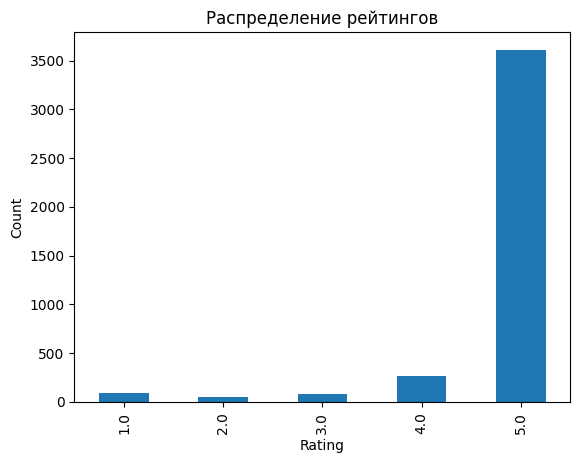

In [17]:
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Распределение рейтингов")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

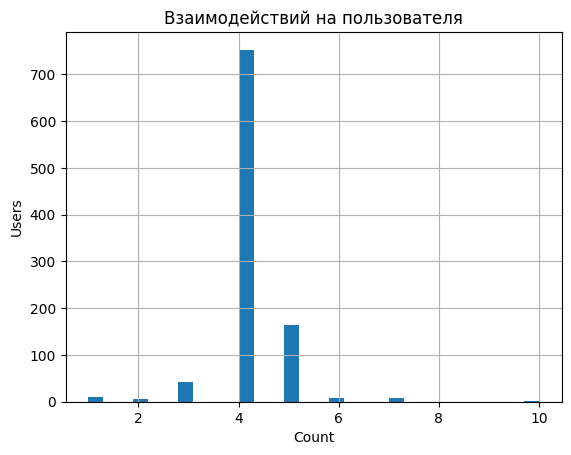

In [18]:
user_counts = df.groupby("user_id").size()
user_counts.hist(bins=30)
plt.title("Взаимодействий на пользователя")
plt.xlabel("Count")
plt.ylabel("Users")
plt.show()

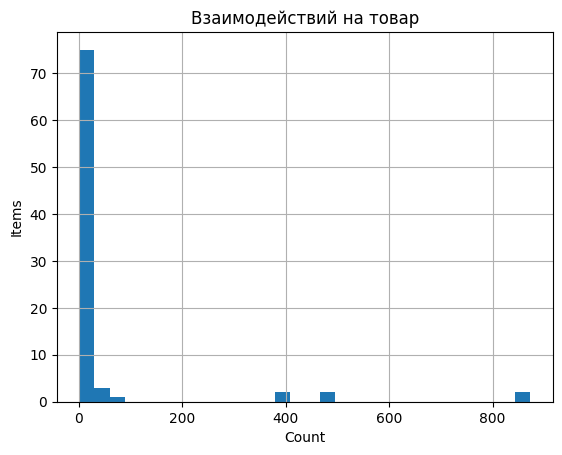

In [19]:
item_counts = df.groupby("item_id").size()
item_counts.hist(bins=30)
plt.title("Взаимодействий на товар")
plt.xlabel("Count")
plt.ylabel("Items")
plt.show()

* Датасет небольшой, но плотный. 
* Распределение рейтингов смещено в сторону высоких оценок.

### Разбиение Leave-one-out

У каждого пользователя оставляем последний по времени товар в test.

In [20]:
def train_test_split(X, user_col = 'user_id', time_col = 'timestamp'):
  full_history = X.sort_values([user_col, time_col]).groupby(user_col)
  test = full_history.tail(1)
  train = full_history.head(-1)
  return train, test

In [21]:
train, test = train_test_split(df)
test

,user_id,item_id,rating,timestamp
3887,A105A034ZG9EHO,B0012Y0ZG2,5.0,1404604800
4005,A10JB7YPWZGRF4,B0012Y0ZG2,5.0,1376352000
5030,A10M2MLE2R0L6K,B019FWRG3C,5.0,1504656000
3560,A10P0NAKKRYKTZ,B0012Y0ZG2,5.0,1458086400
4280,A10ZJZNO4DAVB,B001OHV1H4,5.0,1493337600
...,...,...,...,...
4605,AZCOSCQG73JZ1,B001OHV1H4,5.0,1407110400
4033,AZD3ON9ZMEGL6,B0012Y0ZG2,5.0,1369526400
4471,AZFYUPGEE6KLW,B001OHV1H4,5.0,1451347200
4634,AZJMUP77WBQZQ,B001OHV1H4,5.0,1387497600


### Подготовка матрицы user-item

In [22]:
# маппинг id в индексы
def get_mapping(train_data):
    user_ids = sorted(train_data['user_id'].unique().tolist())
    item_ids = sorted(train_data['item_id'].unique().tolist())

    n_users = len(user_ids)
    n_items = len(item_ids)

    user_idx = range(n_users)
    item_idx = range(n_items)

    user_mapping = dict(zip(user_ids, user_idx)) # {user_id: user_ind}
    item_mapping = dict(zip(item_ids, item_idx)) # {item_id: item_ind}
    return user_mapping, item_mapping

### Baseline: Самые популярные товары

Самая простая рекомендательная система без обучения, на одной статистике будет рекомендовать самые популярные товары.

In [23]:
N = 10

In [24]:
# список товаров, отсортированный в обратном порядке по их количеству в train-выборке
count_items = Counter(train['item_id'])
count_items = list(count_items.items())
count_items.sort(key=lambda x: (-x[1], x[0]))
count_items[:5]

[('B000URXP6E', 849),
 ('B0012Y0ZG2', 524),
 ('B00006L9LC', 489),
 ('B0009RF9DW', 386),
 ('B000FI4S1E', 386)]

При этом будем рекомендовать только те товары, которые пользователь не покупал.

In [25]:
# все самые популярные товары собрали в список и исключили те, которые уже были в истории у пользователя
pred = test.copy()
preds = []
for i, row in pred.iterrows():
  has_rel = list(train[train['user_id'] == row['user_id']]['item_id'])
  cur_preds = [k for k, v in count_items if k not in has_rel][:N]
  preds.append(cur_preds)
pred['preds'] = preds

In [26]:
pred

,user_id,item_id,rating,timestamp,preds
3887,A105A034ZG9EHO,B0012Y0ZG2,5.0,1404604800,"[B0012Y0ZG2, B00006L9LC, B001OHV1H4, B00W259T7..."
4005,A10JB7YPWZGRF4,B0012Y0ZG2,5.0,1376352000,"[B0012Y0ZG2, B00006L9LC, B001OHV1H4, B00W259T7..."
5030,A10M2MLE2R0L6K,B019FWRG3C,5.0,1504656000,"[B000URXP6E, B0012Y0ZG2, B00006L9LC, B0009RF9D..."
3560,A10P0NAKKRYKTZ,B0012Y0ZG2,5.0,1458086400,"[B0012Y0ZG2, B00006L9LC, B001OHV1H4, B00W259T7..."
4280,A10ZJZNO4DAVB,B001OHV1H4,5.0,1493337600,"[B0009RF9DW, B000FI4S1E, B001OHV1H4, B00W259T7..."
...,...,...,...,...,...
4605,AZCOSCQG73JZ1,B001OHV1H4,5.0,1407110400,"[B0009RF9DW, B000FI4S1E, B001OHV1H4, B00W259T7..."
4033,AZD3ON9ZMEGL6,B0012Y0ZG2,5.0,1369526400,"[B0012Y0ZG2, B00006L9LC, B001OHV1H4, B00W259T7..."
4471,AZFYUPGEE6KLW,B001OHV1H4,5.0,1451347200,"[B0009RF9DW, B000FI4S1E, B001OHV1H4, B00W259T7..."
4634,AZJMUP77WBQZQ,B001OHV1H4,5.0,1387497600,"[B0009RF9DW, B000FI4S1E, B001OHV1H4, B00W259T7..."


In [27]:
calculate_metrics(train, pred, item_id='item_id', true_col='item_id')

mrr = 0.4851640959108164
hr = 0.8163471241170535
ndcg = 0.565957789676025
coverage = 0.2631578947368421


### ALS

In [28]:
test.head()

,user_id,item_id,rating,timestamp
3887,A105A034ZG9EHO,B0012Y0ZG2,5.0,1404604800
4005,A10JB7YPWZGRF4,B0012Y0ZG2,5.0,1376352000
5030,A10M2MLE2R0L6K,B019FWRG3C,5.0,1504656000
3560,A10P0NAKKRYKTZ,B0012Y0ZG2,5.0,1458086400
4280,A10ZJZNO4DAVB,B001OHV1H4,5.0,1493337600


In [29]:
rating = list(train['rating'])

# превращение в индексы строк
rows = train['user_id'].astype('category').cat.codes
cols = train['item_id'].astype('category').cat.codes

train_sparse = sparse.csr_matrix((rating, (rows, cols)), shape=(train['user_id'].nunique(), train['item_id'].nunique()))

In [30]:
matrix_size = train_sparse.shape[0]*train_sparse.shape[1] # Number of possible interactions in the matrix
num_purchases = len(train_sparse.nonzero()[0]) # Number of items interacted with
sparsity = 100*(1 - (num_purchases/matrix_size))
sparsity

94.4542804513833

Есть шанс получить хороший результат

In [31]:
algo = implicit.als.AlternatingLeastSquares(factors = 64, regularization = 0.1, iterations = 50, random_state=13, use_gpu=False)
algo.fit((train_sparse).astype('float32'))

  0%|          | 0/50 [00:00<?, ?it/s]

In [32]:
N = 10

In [33]:
def predict(user_vecs, item_vecs, rating_matrix=None, filter_seen=False, k=10):
    id2user = dict(enumerate(train['user_id'].astype('category').cat.categories))
    id2item = dict(enumerate(train['item_id'].astype('category').cat.categories))

    scores = user_vecs @ item_vecs.T

    if filter_seen:
        seen_mask = rating_matrix.toarray().astype(bool)
        scores = scores.copy()
        scores[seen_mask] = -np.inf

    # быстрее чем argsort. Аналог - torch.topk
    # частичная сортировка: k самых больших элементов окажутся справа
    # ind_part - индексы товаров
    ind_part = np.argpartition(scores, -k, axis=1)[:, -k:]

    # вытаскиваем их значения
    # scores_part - реальные скоры
    scores_part = np.take_along_axis(scores, ind_part, axis=1)

    # сортируем внутри top-k
    ind_sorted = np.argsort(-scores_part, axis=1)
    
    # применяем порядок к индексам: финальный top-k, отсортированный по убыванию
    indices = np.take_along_axis(ind_part, ind_sorted, axis=1)

    preds = pd.DataFrame({
        'user_id': range(user_vecs.shape[0]),
        'preds': indices.tolist(),
    })
    preds['user_id'] = preds['user_id'].map(id2user)
    preds['preds'] = preds['preds'].map(lambda inds: [id2item[i] for i in inds])
    return preds

In [34]:
user_vecs = algo.user_factors
item_vecs = algo.item_factors

pred = predict(user_vecs, item_vecs, train_sparse, filter_seen=True, k=N)
pred = pred.merge(test, how='left', on='user_id')

In [35]:
pred.head()

,user_id,preds,item_id,rating,timestamp
0,A105A034ZG9EHO,"[B0012Y0ZG2, B000X2FPXC, B00GHJOM2U, B00112DRH...",B0012Y0ZG2,5.0,1404604800
1,A10JB7YPWZGRF4,"[B0012Y0ZG2, B000X2FPXC, B00GHJOM2U, B00112DRH...",B0012Y0ZG2,5.0,1376352000
2,A10M2MLE2R0L6K,"[B019FWRG3C, B006WYJM8Y, B0010ZBORW, B002GP80E...",B019FWRG3C,5.0,1504656000
3,A10P0NAKKRYKTZ,"[B0012Y0ZG2, B000X2FPXC, B00GHJOM2U, B00112DRH...",B0012Y0ZG2,5.0,1458086400
4,A10ZJZNO4DAVB,"[B000W0C07Y, B001OHV1H4, B006IB5T4W, B000WR2HB...",B001OHV1H4,5.0,1493337600


In [36]:
calculate_metrics(train, pred, item_id='item_id', true_col='item_id')

mrr = 0.5588397812403928
hr = 0.7798165137614679
ndcg = 0.6150473580880469
coverage = 0.9824561403508771


### Выводы

1. Базовая модель показала более высокое значение HR@10 (0.816), что свидетельствует о высокой вероятности попадания релевантного товара в топ рекомендаций. Однако значения MRR@10 (0.485) и NDCG@10 (0.566) оказались ниже, что указывает на более слабое ранжирование внутри списка рекомендаций.
2. Модель ALS показала более низкий HR@10 (0.780), но значительно превзошла базовую модель по метрикам ранжирования: MRR@10 = 0.559 и NDCG@10 = 0.615. Это означает, что при наличии релевантного товара в списке рекомендаций он чаще располагается на более высоких позициях.
3. Большая разница в метрике coverage: для базовой модели она составила 0.26, тогда как для ALS — 0.98. Это говорит о том, что ALS использует значительно более широкий набор товаров и обеспечивает более разнообразные рекомендации.

В ходе экспериментов было замечено, что метрики модели ALS существенно изменяются при варьировании гиперпараметров factors, regularization, iterations. 
Эксперименты со значениями тут не отражены, однако эта особенность была замечена в ходе подбора гиперпараметров.
Вероятно это связано с небольшим размером датасета, где модель может легко уйти в переобучение, просто запоминая параметры.